# Complete CA CNN Classification Pipeline

This notebook contains the complete pipeline for:
1. Data generation
2. Model training (5 models)
3. Evaluation and comparison

**Note**: This will take several hours to complete. Consider running data generation and model training separately.

## 실행 방법

- 필요한 패키지 설치 후 실행
- GPU 사용 권장

## 🔧 Setup - Path Configuration

In [ ]:
# 경로 설정
import sys
import os
from pathlib import Path

print("💻 로컬 환경에서 실행")

# 이 저장소(PDSI)를 어디에 클론해도 동작하도록, 위쪽 폴더에서 "PDSI"라는 이름의
# git 저장소를 찾아 프로젝트 루트로 삼습니다. DATA 폴더 위치가 다르면 환경변수
# PDSI_DATA_ROOT 로 직접 지정하세요(DATA 폴더를 담고 있는 상위 폴더 경로).
def _find_project_root(marker="PDSI"):
    p = Path.cwd().resolve()
    for candidate in [p, *p.parents]:
        if candidate.name == marker and (candidate / ".git").exists():
            return candidate
    return None

_env_override = os.environ.get("PDSI_DATA_ROOT")
if _env_override:
    PROJECT_ROOT = Path(_env_override)
else:
    PROJECT_ROOT = _find_project_root()
    if PROJECT_ROOT is None:
        raise FileNotFoundError(
            "'PDSI' 저장소 폴더를 상위 경로에서 찾지 못했습니다. "
            "환경변수 PDSI_DATA_ROOT 에 DATA 폴더의 상위 경로를 직접 지정하세요."
        )

# DATA 폴더는 PDSI 프로젝트 밖, 형제 폴더로 존재합니다
DATA_ROOT = PROJECT_ROOT.parent / 'DATA'
DATA_DIR = DATA_ROOT / 'CA_77'
MODEL_DIR = DATA_DIR / 'models'
CHECKPOINT_DIR = DATA_DIR / 'checkpoints'
DATA_FILE = DATA_DIR / 'data500_50.pickle'

# 디렉토리 생성
DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n📂 프로젝트 경로: {PROJECT_ROOT}")
print(f"📂 데이터 루트: {DATA_ROOT}")
print(f"📂 데이터 경로: {DATA_DIR}")
print(f"💾 데이터 파일: {DATA_FILE}")

## Import Libraries

In [2]:
import sys
import subprocess

# 필요한 패키지 자동 설치
def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

# TensorFlow 설치 확인 및 설치
try:
    import tensorflow as tf
    print(f"✅ TensorFlow {tf.__version__} 로드 완료")
except ImportError:
    print("⚠️ TensorFlow를 찾을 수 없습니다. 설치를 시작합니다...")
    install_package("tensorflow")
    import tensorflow as tf
    print(f"✅ TensorFlow {tf.__version__} 설치 및 로드 완료")

# 나머지 라이브러리 import
import numpy as np
import numpy.random as rand
from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from sklearn.model_selection import train_test_split

print(f"GPU 사용 가능: {len(tf.config.list_physical_devices('GPU')) > 0}")
print("✅ 라이브러리 로드 완료!")

✅ TensorFlow 2.21.0 로드 완료
GPU 사용 가능: False
✅ 라이브러리 로드 완료!


## 📊 Part 1: Data Generation

Generate training data by simulating Cellular Automata evolution.

In [3]:
# Set to True to generate new data, False to load existing
GENERATE_NEW_DATA = True  # 기존 데이터가 있으면 False로 설정

In [4]:
# Configuration
CA_RULES = [
    8, 6, 2, 34, 38, 12, 10, 14, 26, 30, 58, 62, 74, 78, 106, 110, 40, 44, 42, 46, 136, 140, 138, 142, 154, 158, 168, 172, 170, 174, 186, 190, 130, 134, 162, 166, 234, 238, 202, 206, 24, 28, 56, 60, 152, 156, 184, 188, 4, 18, 22, 36, 50, 54, 72, 76, 90, 94, 104, 108, 122, 126, 132, 146, 150, 160, 164, 178, 182, 200, 204, 218, 222, 232, 236, 250, 254
]

NUM_CLASSES = len(CA_RULES)
GRID_SIZE = 400
IMAGE_SIZE = 20
NUM_GENERATIONS = 20
NUM_SAMPLES_PER_RULE = 500
DENSITY_LEVELS = [1, 2, 3, 4, 5, 6]
CELLS_PER_DENSITY = 50

print(f"📊 설정 완료")
print(f"  - CA 룰: {NUM_CLASSES}개")
print(f"  - 총 샘플: {len(CA_RULES) * NUM_SAMPLES_PER_RULE * len(DENSITY_LEVELS):,}개")

📊 설정 완료
  - CA 룰: 77개
  - 총 샘플: 231,000개


In [5]:
# CA simulation functions
def get_wolfram_rule(rule_number):
    binary_rep = str(bin(rule_number))[2:]
    binary_rep = [0] * (8 - len(binary_rep)) + [int(b) for b in binary_rep]
    mapping = {
        (0,0,0): binary_rep[7], (0,0,1): binary_rep[6],
        (0,1,0): binary_rep[5], (0,1,1): binary_rep[4],
        (1,0,0): binary_rep[3], (1,0,1): binary_rep[2],
        (1,1,0): binary_rep[1], (1,1,1): binary_rep[0],
    }
    return mapping

def get_next_generation(previous_seq, rule):
    seq_length = len(previous_seq) - 2
    sub_seqs = [tuple(previous_seq[i:i + 3]) for i in range(seq_length)]
    new_seq = [rule[sub_seq] for sub_seq in sub_seqs]
    new_seq.insert(0, 0)
    new_seq.append(0)
    return new_seq

def evolve_ca(initial_state, rule_number, num_generations):
    state = initial_state
    rule = get_wolfram_rule(rule_number)
    for _ in range(num_generations):
        state = get_next_generation(state, rule)
    return state

def generate_single_sample(rule_number, density_level, seed=None):
    if seed is not None:
        rand.seed(seed)
    
    y = np.zeros(NUM_CLASSES)
    y[CA_RULES.index(rule_number)] = 1
    
    num_active_cells = CELLS_PER_DENSITY * density_level
    idx = rand.choice(GRID_SIZE, num_active_cells, replace=False)
    initial_state = np.zeros(GRID_SIZE)
    initial_state[idx] = 1
    
    gen_2030 = initial_state
    gen_2050 = evolve_ca(gen_2030, rule_number, NUM_GENERATIONS)
    gen_2070 = evolve_ca(gen_2050, rule_number, NUM_GENERATIONS)
    gen_2090 = evolve_ca(gen_2070, rule_number, NUM_GENERATIONS)
    
    gen_2030_mat = np.array(gen_2030).reshape(IMAGE_SIZE, IMAGE_SIZE)
    gen_2050_mat = np.array(gen_2050).reshape(IMAGE_SIZE, IMAGE_SIZE)
    gen_2070_mat = np.array(gen_2070).reshape(IMAGE_SIZE, IMAGE_SIZE)
    gen_2090_mat = np.array(gen_2090).reshape(IMAGE_SIZE, IMAGE_SIZE)
    
    X = np.array([gen_2030_mat, gen_2050_mat, gen_2070_mat, gen_2090_mat])
    return X, y

print("✅ CA 시뮬레이션 함수 정의 완료!")

✅ CA 시뮬레이션 함수 정의 완료!


In [6]:
if GENERATE_NEW_DATA:
    print("🔄 데이터 생성 시작...")
    print("⏱️ 예상 시간: 약 15-20분\n")
    
    X_list = []
    y_list = []
    
    for rule in tqdm(CA_RULES, desc="Processing rules"):
        for sample_idx in range(NUM_SAMPLES_PER_RULE):
            for density_level in DENSITY_LEVELS:
                seed = 500 * rule + sample_idx
                X_i, y_i = generate_single_sample(rule, density_level, seed=seed)
                X_list.append(X_i)
                y_list.append(y_i)
    
    X = np.array(X_list)
    y = np.array(y_list)
    X = np.transpose(X, (0, 2, 3, 1))
    
    print(f"\n✅ 데이터 생성 완료!")
    print(f"  X shape: {X.shape}")
    print(f"  y shape: {y.shape}")
    
    # Save data
    print(f"\n💾 데이터 저장 중: {DATA_FILE}")
    with open(DATA_FILE, 'wb') as f:
        pickle.dump((X, y), f, pickle.HIGHEST_PROTOCOL)
    print(f"✅ 데이터 저장 완료!")
else:
    print(f"📂 기존 데이터 로드: {DATA_FILE}")
    with open(DATA_FILE, 'rb') as f:
        X, y = pickle.load(f)
    print(f"✅ 데이터 로드 완료! X: {X.shape}, y: {y.shape}")

🔄 데이터 생성 시작...
⏱️ 예상 시간: 약 15-20분



Processing rules:   0%|          | 0/77 [00:00<?, ?it/s]

Processing rules:   1%|▏         | 1/77 [00:08<10:58,  8.67s/it]

Processing rules:   3%|▎         | 2/77 [00:17<10:47,  8.63s/it]

Processing rules:   4%|▍         | 3/77 [00:25<10:41,  8.66s/it]

...

Processing rules:  99%|█████████▊| 76/77 [10:55<00:08,  8.64s/it]

Processing rules: 100%|██████████| 77/77 [11:03<00:00,  8.64s/it]

Processing rules: 100%|██████████| 77/77 [11:03<00:00,  8.62s/it]


✅ 데이터 생성 완료!
  X shape: (231000, 20, 20, 4)
  y shape: (231000, 77)

💾 데이터 저장 중: /Users/yunju/Library/CloudStorage/GoogleDrive-wuj2293@gmail.com/내 드라이브/Research/2026 CA/PDSI_data/CA_77/data500_50.pickle


✅ 데이터 저장 완료!


## 🧠 Part 2: Model Training

Train 5 independent CNN models.

In [7]:
# Training Configuration
INPUT_SHAPE = (20, 20, 4)
BATCH_SIZE = 100
EPOCHS = 100
NUM_MODELS = 5
MODEL_SEEDS = [42, 123, 456, 789, 1011]

print(f"🎯 학습 설정")
print(f"  - 모델 개수: {NUM_MODELS}")
print(f"  - Epochs: {EPOCHS}")
print(f"  - Batch size: {BATCH_SIZE}")

🎯 학습 설정
  - 모델 개수: 5
  - Epochs: 100
  - Batch size: 100


In [8]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)
print(f"📊 데이터 분할")
print(f"  - Training: {len(X_train):,}")
print(f"  - Test: {len(X_test):,}")

📊 데이터 분할
  - Training: 184,800
  - Test: 46,200


In [9]:
# Model building functions
def set_seed(seed):
    np.random.seed(seed)
    tf.random.set_seed(seed)

def build_cnn_model():
    model = models.Sequential([
        layers.InputLayer(input_shape=INPUT_SHAPE),
        layers.Conv2D(32, (3, 3), activation="relu", padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu", padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.BatchNormalization(),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ])
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

print("✅ 모델 빌드 함수 정의 완료!")

✅ 모델 빌드 함수 정의 완료!


In [10]:
# Train all models
results = {}

print("🚀 모델 학습 시작...")
print(f"⏱️ 예상 시간: 약 2-3시간 (GPU 사용 시)\n")

for i in range(NUM_MODELS):
    model_idx = i + 1
    seed = MODEL_SEEDS[i]
    
    print(f"\n{'='*70}")
    print(f"🔵 Model {model_idx} / {NUM_MODELS} (seed={seed})")
    print(f"{'='*70}")
    
    set_seed(seed)
    model = build_cnn_model()
    
    checkpoint_path = str(CHECKPOINT_DIR / f"model_checkpoint_{model_idx}.weights.h5")
    callbacks = [
        ModelCheckpoint(checkpoint_path, save_weights_only=True, monitor='val_loss', 
                       mode='min', save_best_only=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001, verbose=1),
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1)
    ]
    
    history = model.fit(
        X_train, y_train,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_split=0.1,
        callbacks=callbacks,
        verbose=2
    )
    
    score = model.evaluate(X_test, y_test, verbose=0)
    print(f"\n📊 Test Accuracy: {score[1]:.4f}")
    print(f"📊 Test Loss: {score[0]:.4f}")
    
    model_path = str(MODEL_DIR / f"model_{model_idx}.keras")
    model.save(model_path)
    print(f"💾 Model saved: {model_path}")
    
    results[f"model_{model_idx}"] = {
        "test_accuracy": score[1],
        "test_loss": score[0],
        "seed": seed,
        "epochs_trained": len(history.history['loss'])
    }

print("\n" + "="*70)
print("🎉 모든 모델 학습 완료!")
print("="*70)

🚀 모델 학습 시작...
⏱️ 예상 시간: 약 2-3시간 (GPU 사용 시)


🔵 Model 1 / 5 (seed=42)


/Users/yunju/ml-projects/tensorflow-env/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/100



Epoch 1: val_loss improved from None to 0.53512, saving model to /Users/yunju/Library/CloudStorage/GoogleDrive-wuj2293@gmail.com/내 드라이브/Research/2026 CA/PDSI_data/CA_77/checkpoints/model_checkpoint_1.weights.h5



Epoch 1: finished saving model to /Users/yunju/Library/CloudStorage/GoogleDrive-wuj2293@gmail.com/내 드라이브/Research/2026 CA/PDSI_data/CA_77/checkpoints/model_checkpoint_1.weights.h5


...


Epoch 23: val_loss did not improve from 0.29792


1664/1664 - 36s - 22ms/step - accuracy: 0.9198 - loss: 0.1863 - val_accuracy: 0.8593 - val_loss: 0.3096 - learning_rate: 1.2500e-04


Epoch 23: early stopping


Restoring model weights from the end of the best epoch: 18.



📊 Test Accuracy: 0.8572
📊 Test Loss: 0.3022
💾 Model saved: /Users/yunju/Library/CloudStorage/GoogleDrive-wuj2293@gmail.com/내 드라이브/Research/2026 CA/PDSI_data/CA_77/models/model_5.keras

🎉 모든 모델 학습 완료!


## 📈 Part 3: Results Summary

In [11]:
print("\n📊 학습 결과 요약")
print("="*70)
for model_name, result in results.items():
    print(f"{model_name}:")
    print(f"  - Accuracy: {result['test_accuracy']:.4f}")
    print(f"  - Loss: {result['test_loss']:.4f}")
    print(f"  - Epochs: {result['epochs_trained']}")
    print(f"  - Seed: {result['seed']}")
    print()

avg_accuracy = np.mean([r['test_accuracy'] for r in results.values()])
avg_loss = np.mean([r['test_loss'] for r in results.values()])

print(f"평균 Test Accuracy: {avg_accuracy:.4f}")
print(f"평균 Test Loss: {avg_loss:.4f}")


📊 학습 결과 요약
model_1:
  - Accuracy: 0.8482
  - Loss: 0.3161
  - Epochs: 20
  - Seed: 42

model_2:
  - Accuracy: 0.8469
  - Loss: 0.3221
  - Epochs: 21
  - Seed: 123

model_3:
  - Accuracy: 0.8520
  - Loss: 0.3155
  - Epochs: 23
  - Seed: 456

model_4:
  - Accuracy: 0.8488
  - Loss: 0.3224
  - Epochs: 21
  - Seed: 789

model_5:
  - Accuracy: 0.8572
  - Loss: 0.3022
  - Epochs: 23
  - Seed: 1011

평균 Test Accuracy: 0.8506
평균 Test Loss: 0.3157


💾 비교 그래프 저장: /Users/yunju/Library/CloudStorage/GoogleDrive-wuj2293@gmail.com/내 드라이브/Research/2026 CA/PDSI_data/CA_77/models/model_comparison.png


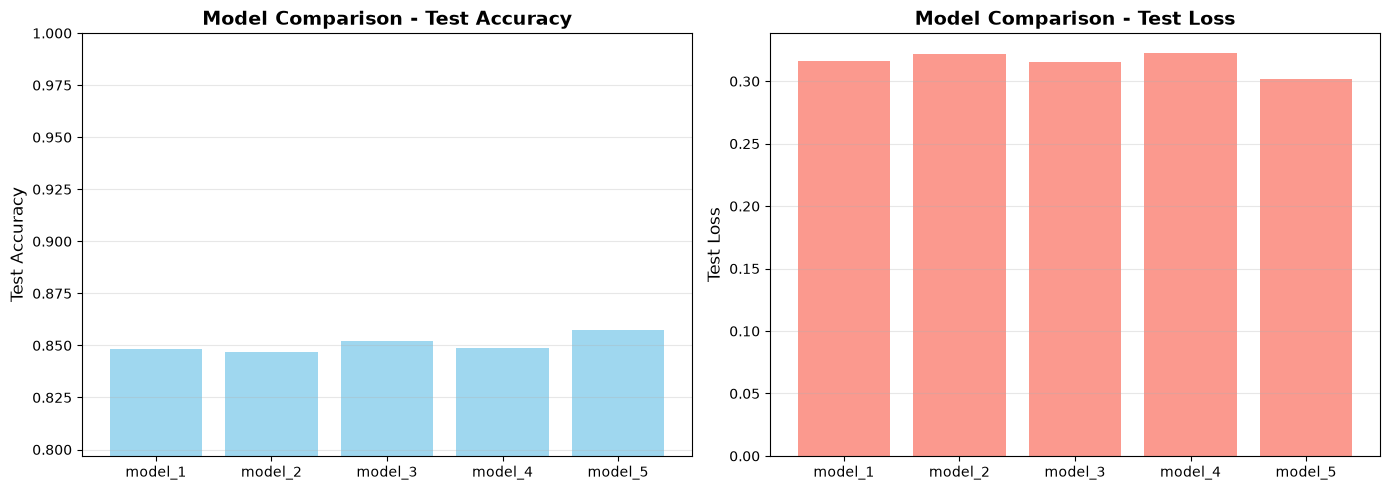


✅ 전체 파이프라인 완료!


In [12]:
# Visualization
model_names = list(results.keys())
accuracies = [results[m]['test_accuracy'] for m in model_names]
losses = [results[m]['test_loss'] for m in model_names]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
ax1.bar(model_names, accuracies, color='skyblue', alpha=0.8)
ax1.set_ylabel('Test Accuracy', fontsize=12)
ax1.set_title('Model Comparison - Test Accuracy', fontsize=14, fontweight='bold')
ax1.set_ylim([min(accuracies) - 0.05, 1.0])
ax1.grid(True, alpha=0.3, axis='y')

# Loss comparison
ax2.bar(model_names, losses, color='salmon', alpha=0.8)
ax2.set_ylabel('Test Loss', fontsize=12)
ax2.set_title('Model Comparison - Test Loss', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
comparison_path = str(MODEL_DIR / 'model_comparison.png')
plt.savefig(comparison_path, dpi=150, bbox_inches='tight')
print(f"💾 비교 그래프 저장: {comparison_path}")
plt.show()

print("\n✅ 전체 파이프라인 완료!")